In [1]:
import sys

print(sys.executable)

c:\Users\Administrator\Desktop\PROJECTS\instagram-spam-detection\venv\Scripts\python.exe


In [37]:
import pandas as pd

df = pd.read_csv("../data/raw/Youtube01-Psy.csv")

print(df.head())
print(df.columns)

                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

   CLASS  
0      1  
1      1  
2      1  
3      1  
4      1  
Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dt

In [38]:
import glob
import pandas as pd

files = glob.glob("../data/raw/*.csv")

dataframes = []

for file in files:
    temp = pd.read_csv(file)
    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

print(df.shape)
print(df.head())

(1956, 5)
                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

   CLASS  
0      1  
1      1  
2      1  
3      1  
4      1  


In [39]:
print(df.info())
print(df.isnull().sum())
print(df.columns)
print(df["CLASS"].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1956 non-null   str  
 1   AUTHOR      1956 non-null   str  
 2   DATE        1711 non-null   str  
 3   CONTENT     1956 non-null   str  
 4   CLASS       1956 non-null   int64
dtypes: int64(1), str(4)
memory usage: 397.8 KB
None
COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
CLASS           0
dtype: int64
Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dtype='str')
CLASS
1    1005
0     951
Name: count, dtype: int64


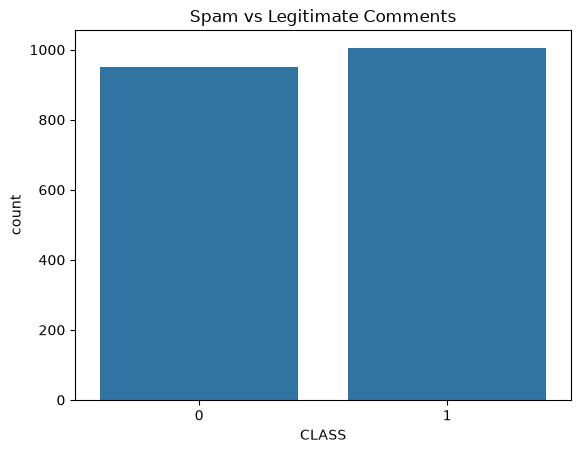

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["CLASS"])

plt.title("Spam vs Legitimate Comments")
plt.show()

In [41]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
df["clean_comment"] = df["CONTENT"].apply(clean_text)

In [43]:
print(df["CLASS"].value_counts())

CLASS
1    1005
0     951
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_comment"],
    df["CLASS"],
    test_size=0.2,
    random_state=42,
    stratify=df["CLASS"]
)

In [47]:
# Check the size (number of rows) in each split
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# View the first few rows of the training comments and their labels
print("\nTraining Comments:")
print(X_train.head())

print("\nTraining Labels:")
print(y_train.head())

Training data shape: (1564,)
Testing data shape: (392,)

Training Comments:
281     video views million people earth
884       head like years ago time flies
70                              billions
1364         wtf subscribe channel thanx
706                                  omg
Name: clean_comment, dtype: str

Training Labels:
281     0
884     0
70      0
1364    1
706     0
Name: CLASS, dtype: int64


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [71]:
ngram_range=(1,2)

In [84]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/spam_model.pkl"
)

joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [87]:
y_pred = model.predict(X_test_tfidf)

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8877551020408163
Precision: 0.9197860962566845
Recall: 0.8557213930348259
F1 Score: 0.8865979381443299
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       191
           1       0.92      0.86      0.89       201

    accuracy                           0.89       392
   macro avg       0.89      0.89      0.89       392
weighted avg       0.89      0.89      0.89       392



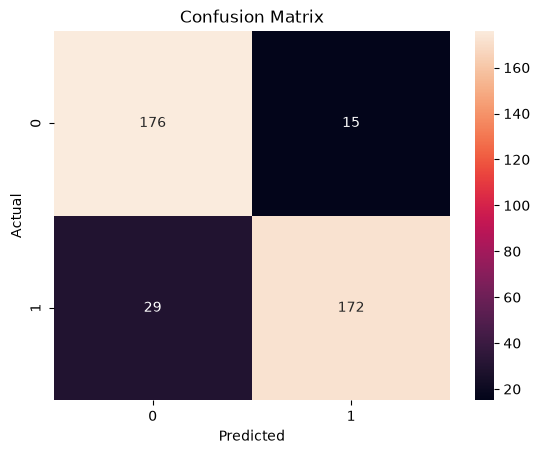

In [89]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [90]:
LogisticRegression()
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

# Generate the predictions so the comparison table can use them
lr_pred = lr.predict(X_test_tfidf)

In [91]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

In [92]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Define a helper function to calculate all four metrics at once
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

# 2. Calculate metrics for each of your trained models
# (Make sure 'lr_pred' matches whatever variable name you used for Logistic Regression)
lr_metrics = get_metrics(y_test, lr_pred) 
nb_metrics = get_metrics(y_test, nb_pred)
svm_metrics = get_metrics(y_test, svm_pred)

# 3. Create a clean pandas DataFrame to display the comparison
comparison_table = pd.DataFrame(
    [lr_metrics, nb_metrics, svm_metrics],
    index=['Logistic Regression', 'Naive Bayes', 'Linear SVM']
)

# Display the table rounded to 4 decimal places
print(comparison_table.round(4))

                     Accuracy  Precision  Recall      F1
Logistic Regression    0.8878     0.9198  0.8557  0.8866
Naive Bayes            0.8776     0.8400  0.9403  0.8873
Linear SVM             0.9005     0.9355  0.8657  0.8992


In [94]:
comment = ["Congratulations you won a free prize click here"]

comment_vector = vectorizer.transform(comment)

prediction = model.predict(comment_vector)[0]

probability = model.predict_proba(comment_vector)[0]

if prediction == 1:
    result = "SPAM"
    confidence = probability[1] * 100
else:
    result = "NOT SPAM"
    confidence = probability[0] * 100

print(f"Prediction: {result}")
print(f"Confidence: {confidence:.2f}%")
print(f"Not Spam Probability: {probability[0] * 100:.2f}%")
print(f"Spam Probability: {probability[1] * 100:.2f}%")

Prediction: SPAM
Confidence: 83.46%
Not Spam Probability: 16.54%
Spam Probability: 83.46%


In [95]:
import joblib
from pathlib import Path

# Go from notebooks/ to the project root
project_root = Path.cwd().parent

# Create models folder if it doesn't exist
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

# Save model and vectorizer
joblib.dump(model, models_dir / "spam_model.pkl")
joblib.dump(vectorizer, models_dir / "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("Model:", models_dir / "spam_model.pkl")
print("Vectorizer:", models_dir / "tfidf_vectorizer.pkl")

Model saved successfully!
Model: c:\Users\Administrator\Desktop\PROJECTS\instagram-spam-detection\models\spam_model.pkl
Vectorizer: c:\Users\Administrator\Desktop\PROJECTS\instagram-spam-detection\models\tfidf_vectorizer.pkl


In [96]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "albert-base-v2"
)
tokens = tokenizer(
    "Congratulations! You won a free prize!",
    padding="max_length",
    truncation=True,
    max_length=128
)

In [97]:
feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

top_spam = coefficients.argsort()[-20:]

for index in reversed(top_spam):
    print(feature_names[index], coefficients[index])

check 5.609550665333216
subscribe 4.3343421319369995
please 3.507590960945892
channel 3.034917317669072
guys 1.6381998977160157
like comment 1.5954903568346377
href 1.5458857913766262
check video 1.5251294224338114
comment 1.4774823651438485
free 1.4395383173699243
videos 1.4051742725038274
new 1.3955898124832902
share 1.328277912378147
youtube 1.2288912258340339
hey 1.2267031488767512
follow 1.1994661024622144
subscribers 1.1847124169853407
make 1.179853149516197
click 1.1581968178840474
playlist 1.0473950435530088
